In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *

In [2]:
from config import dir_config
from src.utils import pmf_utils, classification_utils

raw_dir = Path(dir_config.data.raw)
processed_dir = Path(dir_config.data.processed)

filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)

In [3]:
subjects_map, grp_indices = classification_utils.get_subject_classification_ids(processed_metadata)

PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


## Plot group-wise psychometric function

In [4]:
def new_accumulators():
    """Empty accumulators for positive-prior and equal-prior psychometric data."""
    return {k: {"coh": [], "psych": [], "model": [], "x_hat": [], "y_hat": []} for k in ("pos", "eq")}


def collect_psych(data, accum):
    """Fit psychometric data for both color conditions and append to accum."""
    for key, color_val in [("pos", 1), ("eq", 0)]:
        coh, psych, model, x_hat, y_hat = pmf_utils.get_psychometric_data(data[data["color"] == color_val])
        for field, val in zip(["coh", "psych", "model", "x_hat", "y_hat"], [coh, psych, model, x_hat, y_hat]):
            accum[key][field].append(val)


def plot_mean_psych(ax, accum, pos_color, eq_color, err_style):
    """Plot group-mean psychometric curve with error bars and fitted line."""
    for key, color, label in [("pos", pos_color, "Positive Prior"), ("eq", eq_color, "Equal Prior")]:
        coh_arr = np.array(accum[key]["coh"])
        psych_arr = np.array(accum[key]["psych"])
        x_hat_arr = np.array(accum[key]["x_hat"])
        mean_coh, mean_psych = np.mean(coh_arr, axis=0), np.mean(psych_arr, axis=0)
        mean_x_hat = np.mean(x_hat_arr, axis=0)
        ax.plot(mean_coh, mean_psych, color=color, ls="", marker="o", ms=12, mec="k", label=label)
        ax.errorbar(mean_coh, mean_psych, yerr=stats.sem(psych_arr, axis=0), color=color, ls="", marker="o", ms=12, mec="k", **err_style)
        fit = pmf_utils.fit_psychometric_function(mean_coh, mean_psych, trial_counts=None, model_type="logit_4")
        ax.plot(mean_x_hat, fit.predict(mean_x_hat), color=color, ls="-", lw=4)

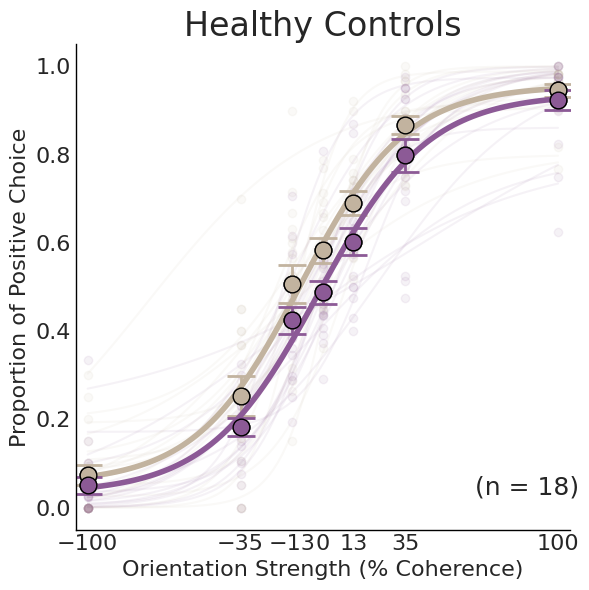

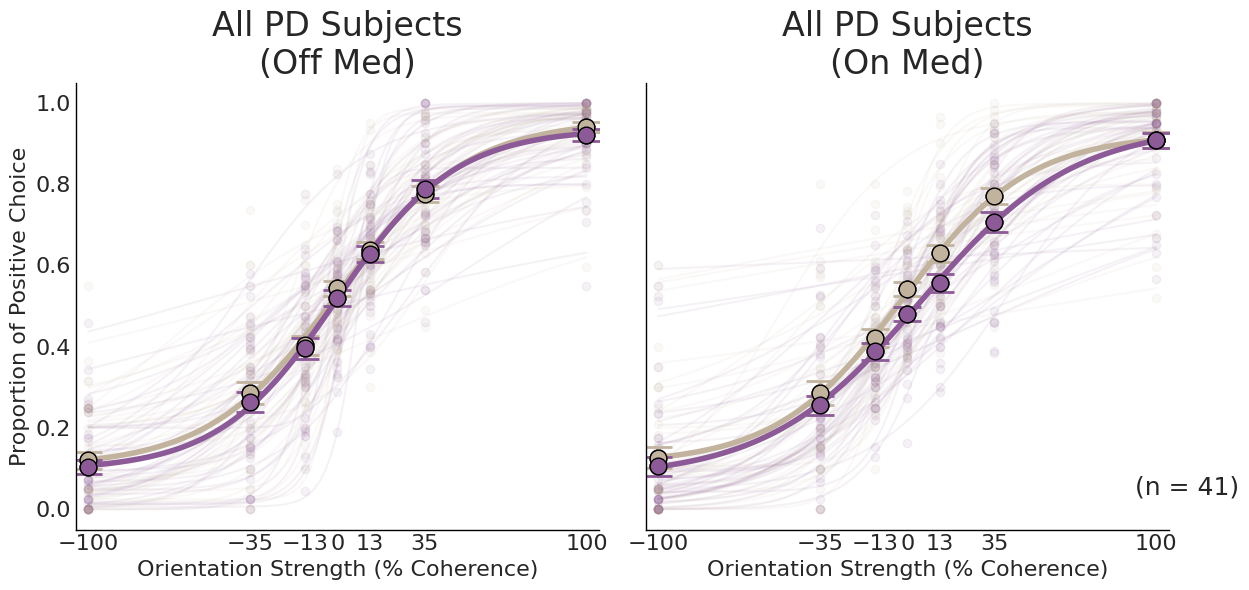

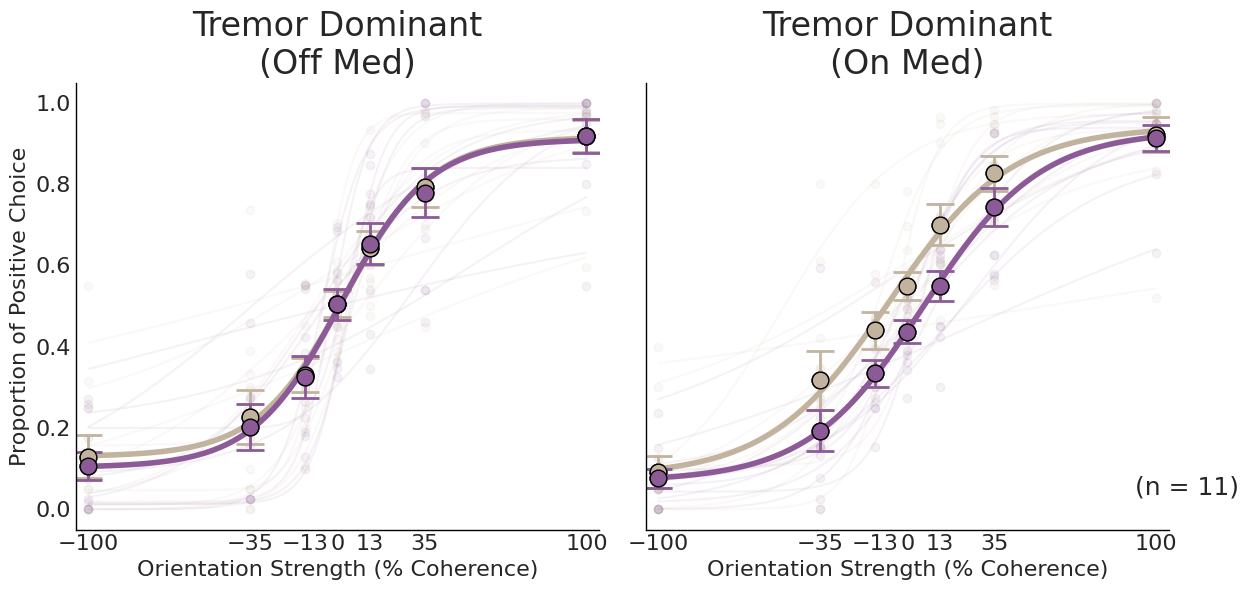

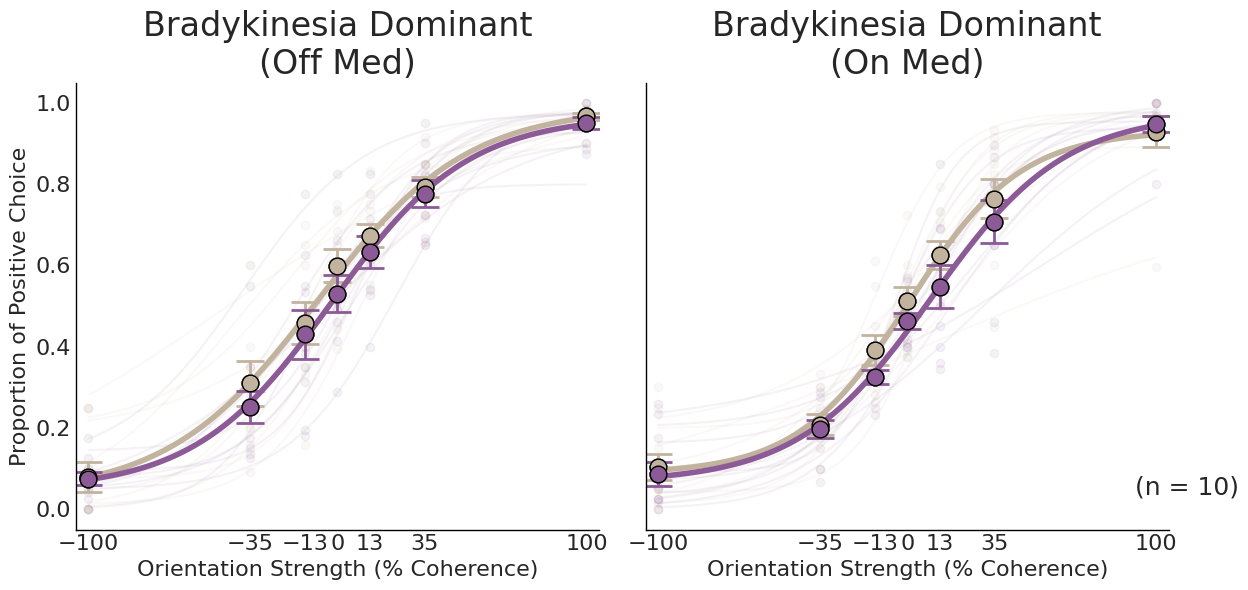

In [5]:
pos_color, eq_color = "#C2B39F", "#8C5A96"
alpha = 0.08
err_style = {"elinewidth": 2, "capsize": 10, "capthick": 2}
suptitle_map = {
    "all": "All PD Subjects",
    "tremor_dominant": "Tremor Dominant",
    "bradykinesia_dominant": "Bradykinesia Dominant",
    "healthy": "Healthy Controls",
}
for group, sub_ids in subjects_map.items():
    suptitle = suptitle_map[group]
    if group != "healthy":
        fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    else:
        fig, _ax = plt.subplots(1, 1, figsize=(6, 6))
        ax = np.array([_ax])

    off, on = new_accumulators(), new_accumulators()
    for sid in sub_ids:
        subj_data = filtered_data[filtered_data["subject_id"] == sid].sort_values("medication")

        if group == "healthy":
            collect_psych(subj_data, off)
            for key, color in [("pos", pos_color), ("eq", eq_color)]:
                ax[0].plot(off[key]["coh"][-1], off[key]["psych"][-1], color=color, marker="o", ls="", alpha=alpha)
                ax[0].plot(off[key]["x_hat"][-1], off[key]["y_hat"][-1], color=color, ls="-", alpha=alpha)
        else:
            for med in subj_data["medication"].unique():
                accum, ax_i = (off, 0) if med == "off" else (on, 1)
                collect_psych(subj_data[subj_data["medication"] == med], accum)
                for key, color in [("pos", pos_color), ("eq", eq_color)]:
                    ax[ax_i].plot(accum[key]["coh"][-1], accum[key]["psych"][-1], color=color, marker="o", ls="", alpha=alpha)
                    ax[ax_i].plot(accum[key]["x_hat"][-1], accum[key]["y_hat"][-1], color=color, ls="-", alpha=alpha)

    if group != "healthy":
        plot_mean_psych(ax[0], off, pos_color, eq_color, err_style)
        plot_mean_psych(ax[1], on, pos_color, eq_color, err_style)
    else:
        plot_mean_psych(ax[0], off, pos_color, eq_color, err_style)

    # ── Styling ──
    for a in ax:
        a.set_xticks([-100, -35, -13, 0, 13, 35, 100])
        a.tick_params(labelsize=16)
        for sp in ["top", "right"]:
            a.spines[sp].set_visible(False)
    ax[0].set(xlabel="Orientation Strength (% Coherence)", ylabel="Proportion of Positive Choice", xlim=(-105, 105), ylim=(-0.05, 1.05), title=f"{suptitle}{'' if group == 'healthy' else '\n(Off Med)'}")
    if group != "healthy":
        ax[1].set(xlabel="Orientation Strength (% Coherence)", xlim=(-105, 105), ylim=(-0.05, 1.05), title=f"{suptitle}\n(On Med)")
        fig.text(0.95, 0.2, f"(n = {len(sub_ids)})", fontsize=18, ha="left", va="top")
    else:
        fig.text(0.8, 0.2, f"(n = {len(sub_ids)})", fontsize=18, ha="left", va="top")
    fig.tight_layout()

## Statistical tests on PMF params

In [6]:
psych_columns = [
    "positive_psych_alpha",
    "positive_psych_beta",
    "equal_psych_alpha",
    "equal_psych_beta",
    "positive_bias",
    "equal_bias",
]

psych_params = processed_metadata[psych_columns]

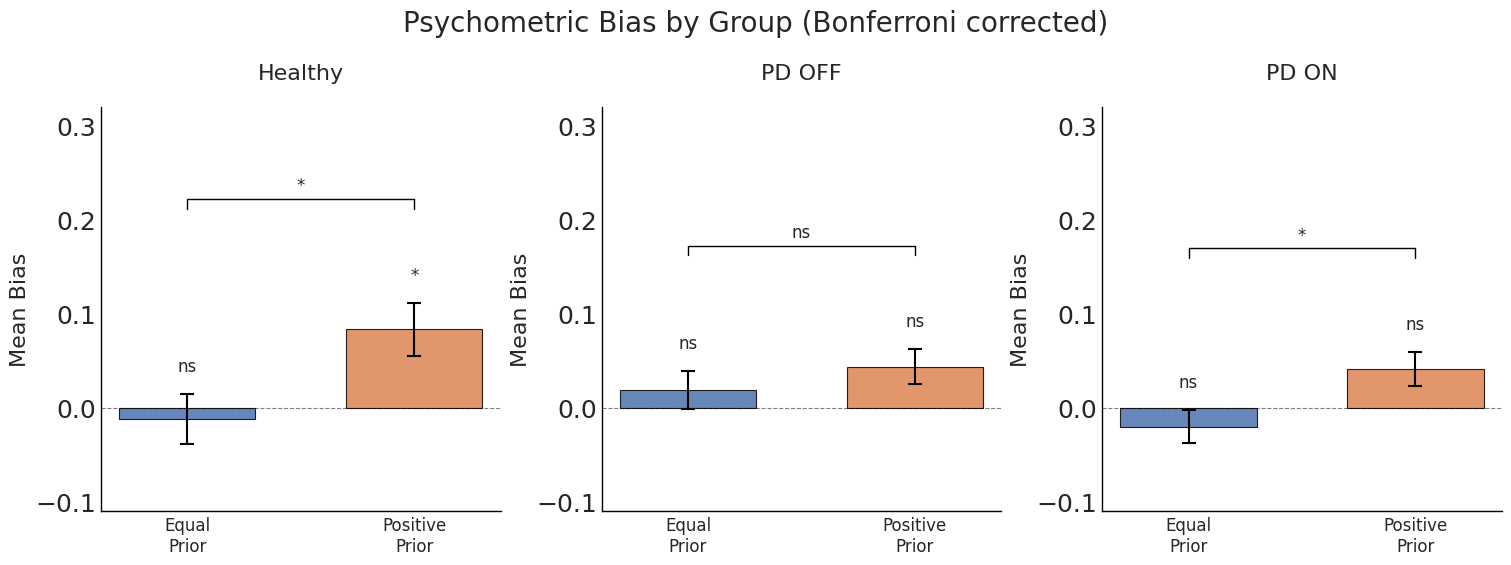

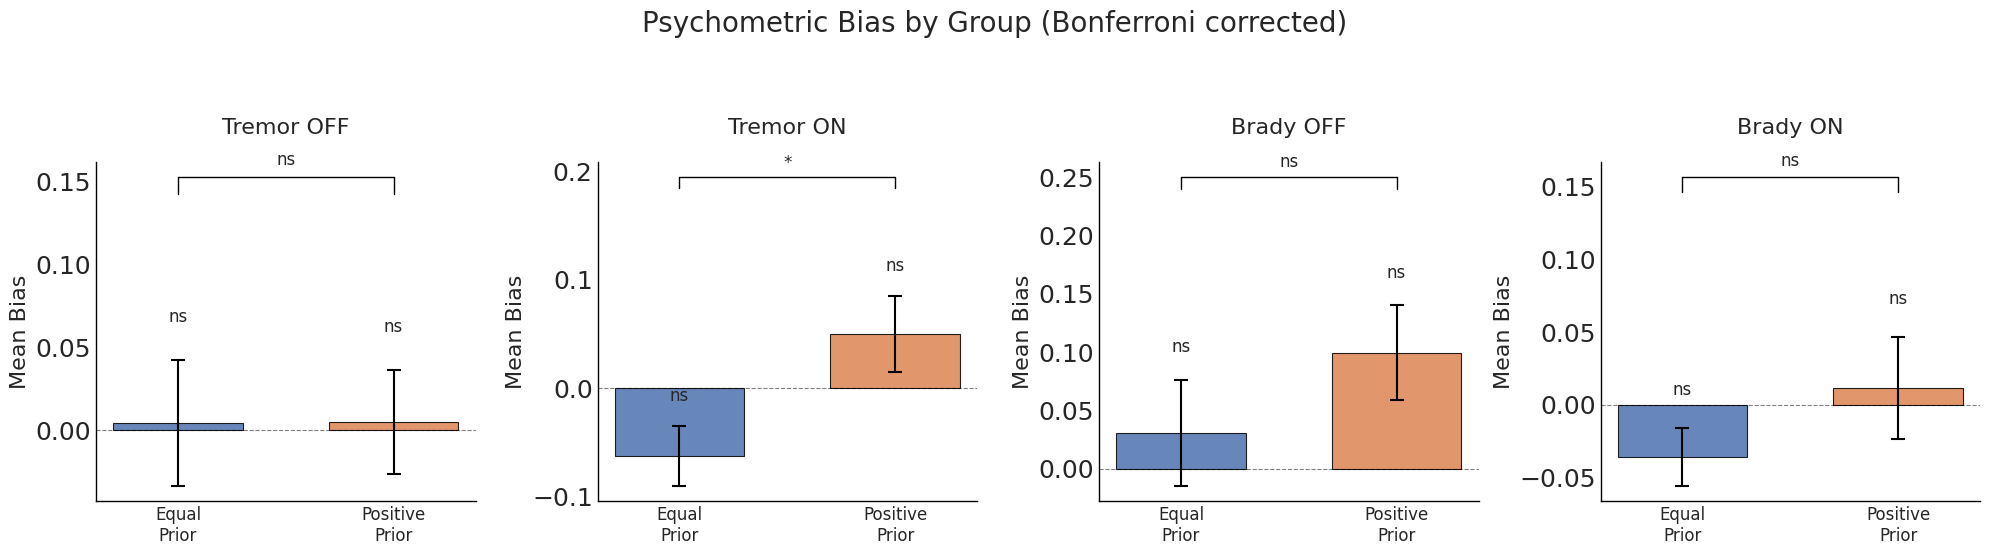

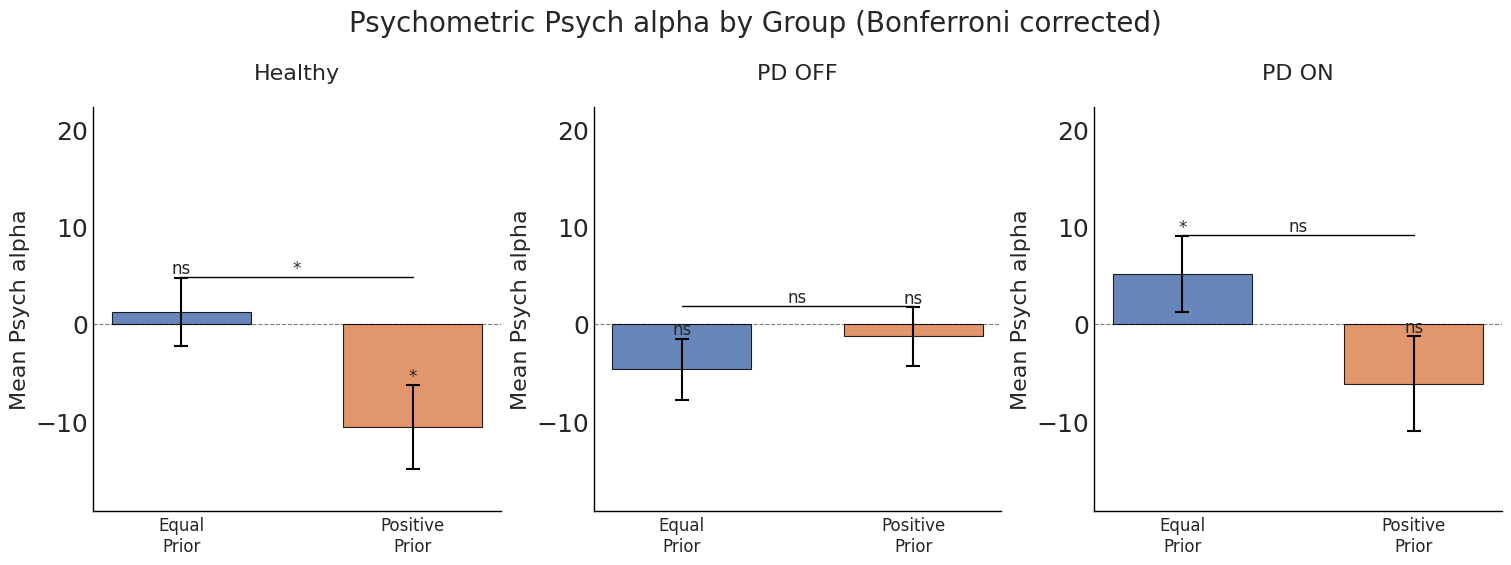

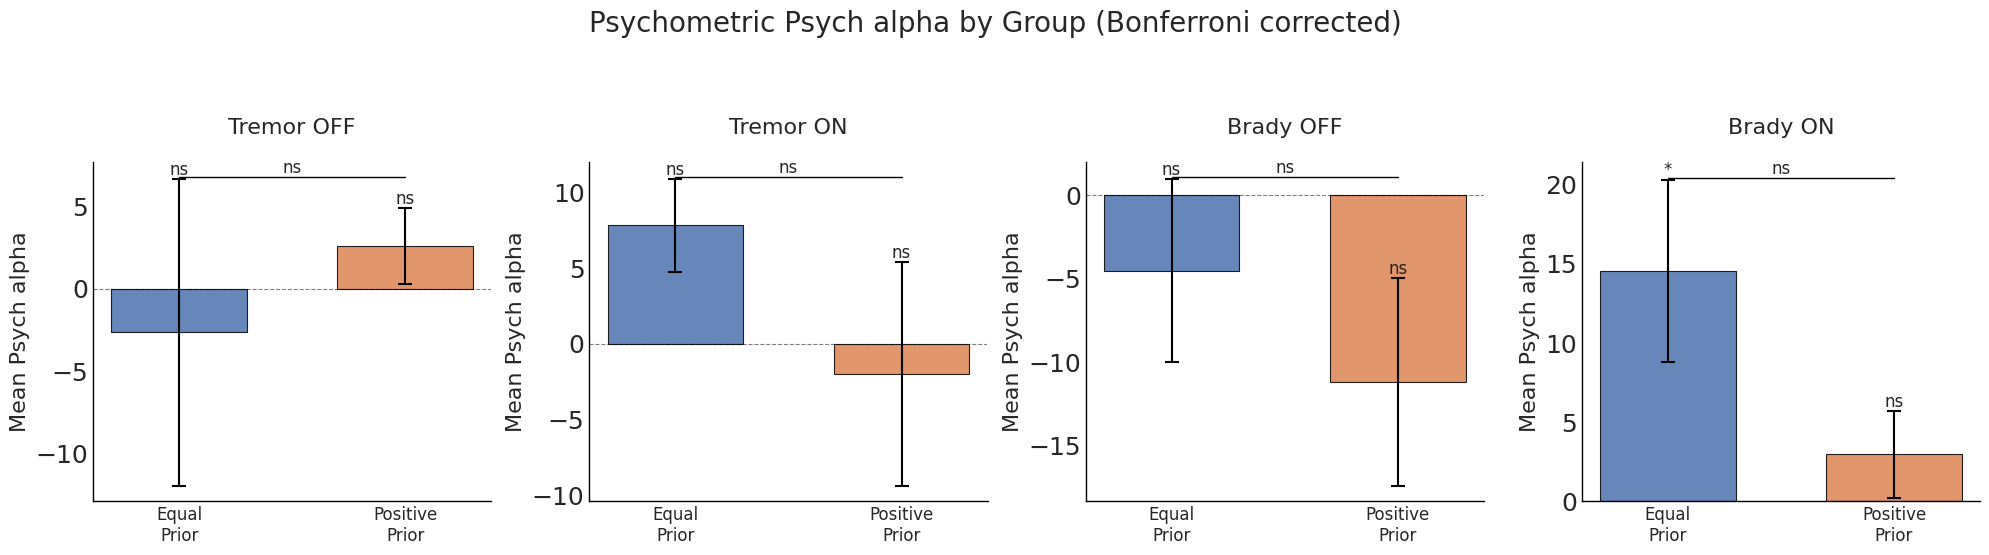

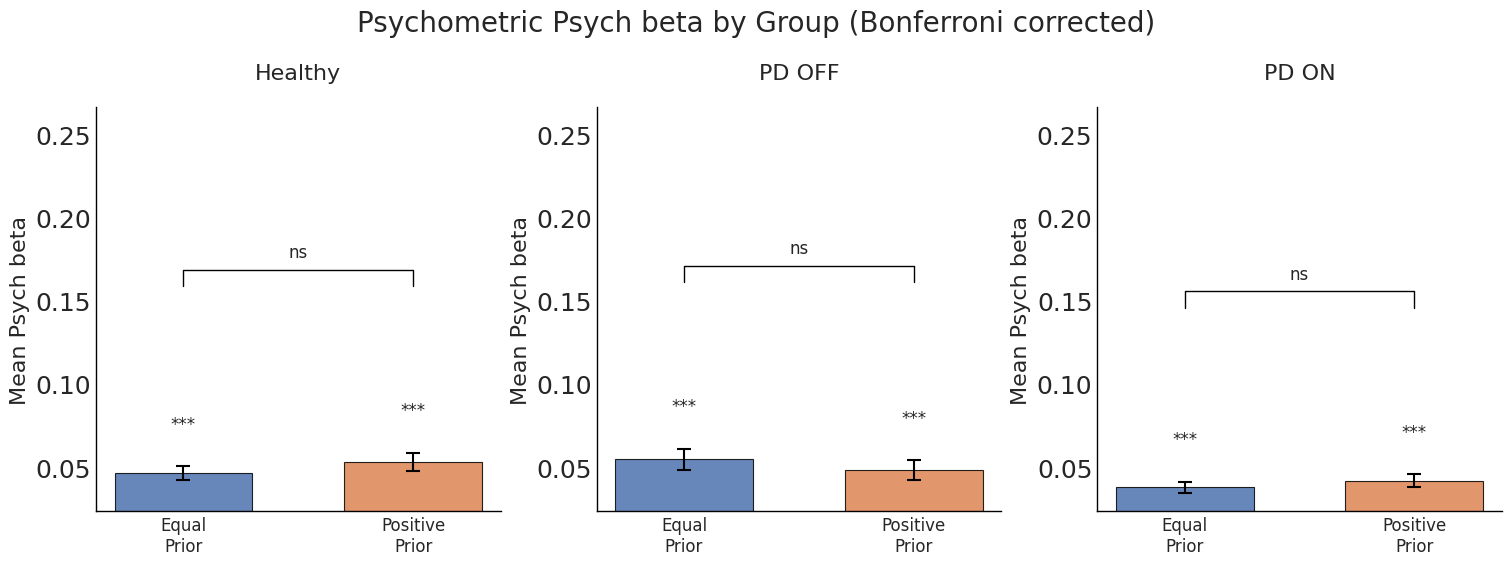

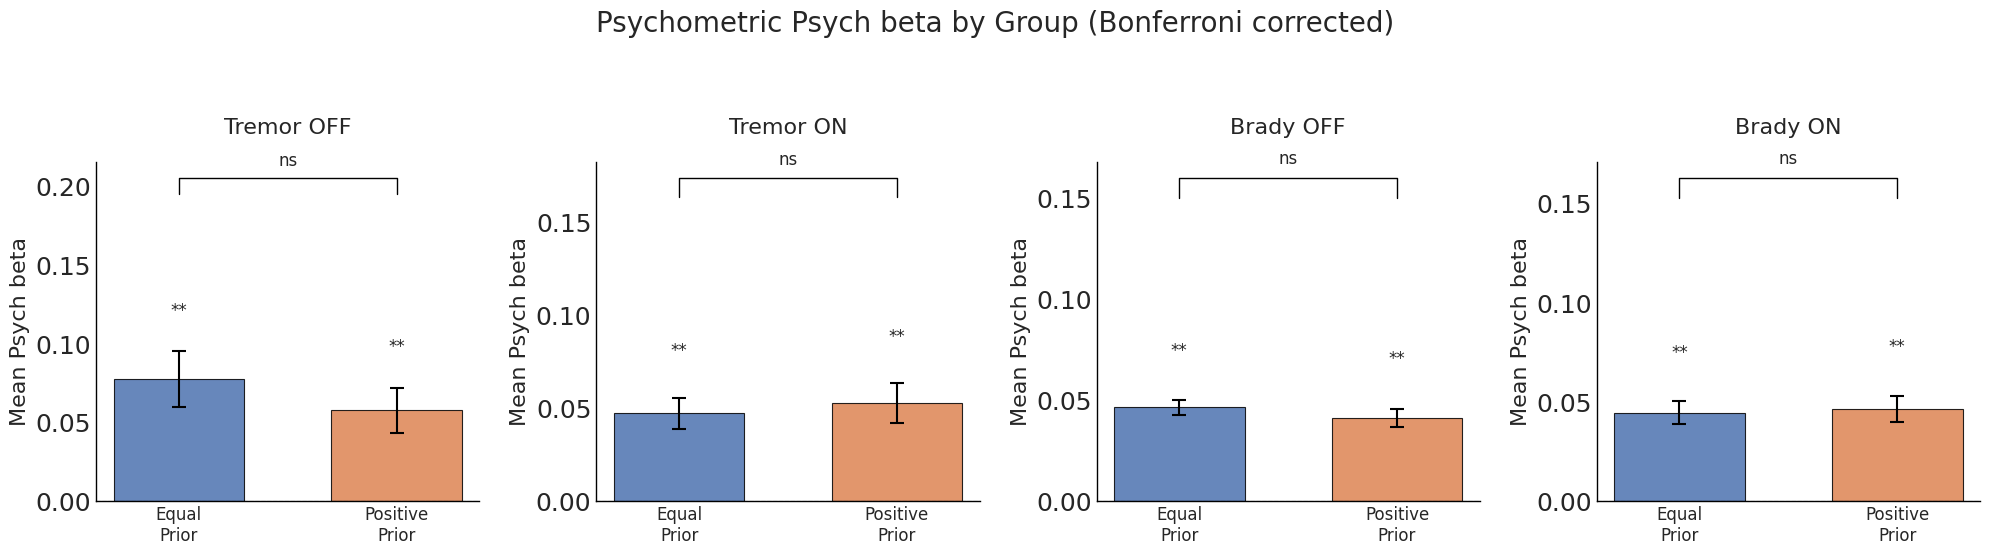

In [7]:
from src.utils.stats_utils import wilcoxon_battery
from scipy import stats as scipy_stats

test_labels = ["equal", "positive"]
test_xlabels = ["Equal\nPrior", "Positive\nPrior"]
bar_colors = ["#4C72B0", "#DD8452"]
bar_x = np.array([0, 1])

group_order = ["healthy", "pd_off", "pd_on", "tremor_off", "tremor_on", "brady_off", "brady_on"]
group_titles = {
    "healthy": "Healthy",
    "pd_off": "PD OFF",
    "pd_on": "PD ON",
    "tremor_off": "Tremor OFF",
    "tremor_on": "Tremor ON",
    "brady_off": "Brady OFF",
    "brady_on": "Brady ON",
}


for var in ["bias", "psych_alpha", "psych_beta"]:
    fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))

    y_min, y_max = np.inf, -np.inf
    for grp in group_order:
        if grp in ["healthy", "pd_off", "pd_on"]:
            ax = axes1[["healthy", "pd_off", "pd_on"].index(grp)]
        else:
            ax = axes2[["tremor_off", "tremor_on", "brady_off", "brady_on"].index(grp)]
        group_data = psych_params.loc[grp_indices[grp]]
        pos_centered = group_data[f"positive_{var}"] if var != "bias" else group_data[f"positive_{var}"] - 0.5
        eq_centered = group_data[f"equal_{var}"] if var != "bias" else group_data[f"equal_{var}"] - 0.5

        results = wilcoxon_battery(
            tests={
                "equal": (eq_centered,),
                "positive": (pos_centered,),
                "positive_vs_equal": (group_data[f"positive_{var}"], group_data[f"equal_{var}"]),
            },
            print_results=False,
        ).set_index("test")

        diffs = {
            "equal": eq_centered,
            "positive": pos_centered,
        }

        bar_tops = {}
        for xi, (test_name, color) in enumerate(zip(test_labels, bar_colors)):
            vals = diffs[test_name].values
            mean = np.mean(vals)
            sem = scipy_stats.sem(vals)

            ax.bar(xi, mean, color=color, edgecolor="k", linewidth=0.8, width=0.6, alpha=0.85)
            ax.errorbar(xi, mean, yerr=sem, fmt="none", color="k", capsize=5, elinewidth=1.5, capthick=1.5)

            corr_p = results.loc[test_name, "corrected_p"]
            star = "***" if corr_p < 0.001 else "**" if corr_p < 0.01 else "*" if corr_p < 0.05 else "ns"
            ax.text(xi, mean + sem + 0.02, star, ha="center", va="bottom", fontsize=12)

            bar_tops[test_name] = mean + sem
            y_min = min(y_min, mean - sem)
            y_max = max(y_max, mean + sem + 0.08)

        bracket_y = max(bar_tops.values()) + 0.10
        p_vs_eq = results.loc["positive_vs_equal", "corrected_p"]
        p_str = "***" if p_vs_eq < 0.001 else "**" if p_vs_eq < 0.01 else "*" if p_vs_eq < 0.05 else "ns# p < 0.001" if p_vs_eq < 0.001 else "ns"  # f"p = {p_vs_eq:.3f}"
        ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + 0.01, bracket_y + 0.01, bracket_y], color="k", lw=1)
        ax.text(0.5, bracket_y + 0.015, p_str, ha="center", va="bottom", fontsize=12)

        y_max = max(y_max, bracket_y + 0.06)

        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
        ax.set_xticks(bar_x)
        ax.set_xticklabels(test_xlabels, fontsize=12)
        ax.set_title(group_titles[grp], fontsize=16, pad=20)
        ax.set_ylabel(f"Mean {var.capitalize().replace('_', ' ')}")
        ax.grid(False)

    pad = (y_max - y_min) * 0.05
    for ax in axes1:
        ax.set_ylim(y_min - pad, y_max + pad)

    fig1.suptitle(f"Psychometric {var.capitalize().replace('_', ' ')} by Group (Bonferroni corrected)", y=1.1, fontsize=20)
    fig2.suptitle(f"Psychometric {var.capitalize().replace('_', ' ')} by Group (Bonferroni corrected)", y=1.1, fontsize=20)
    plt.tight_layout()
    plt.show()

## Dissemination

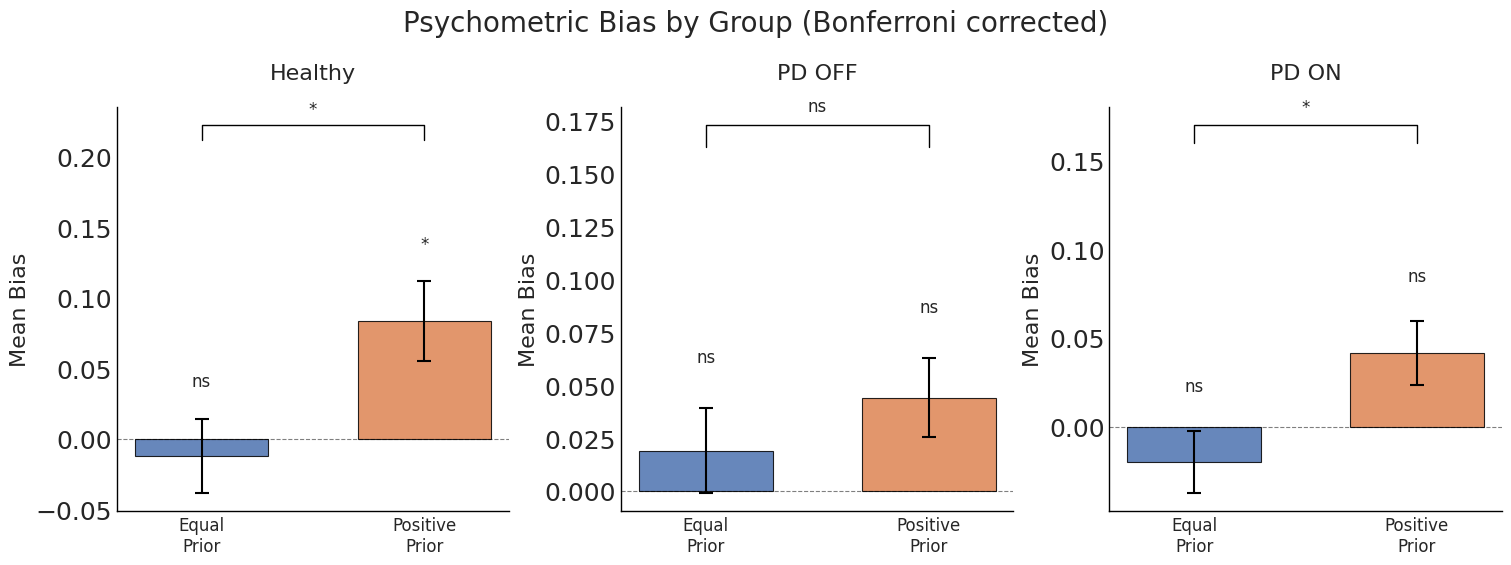

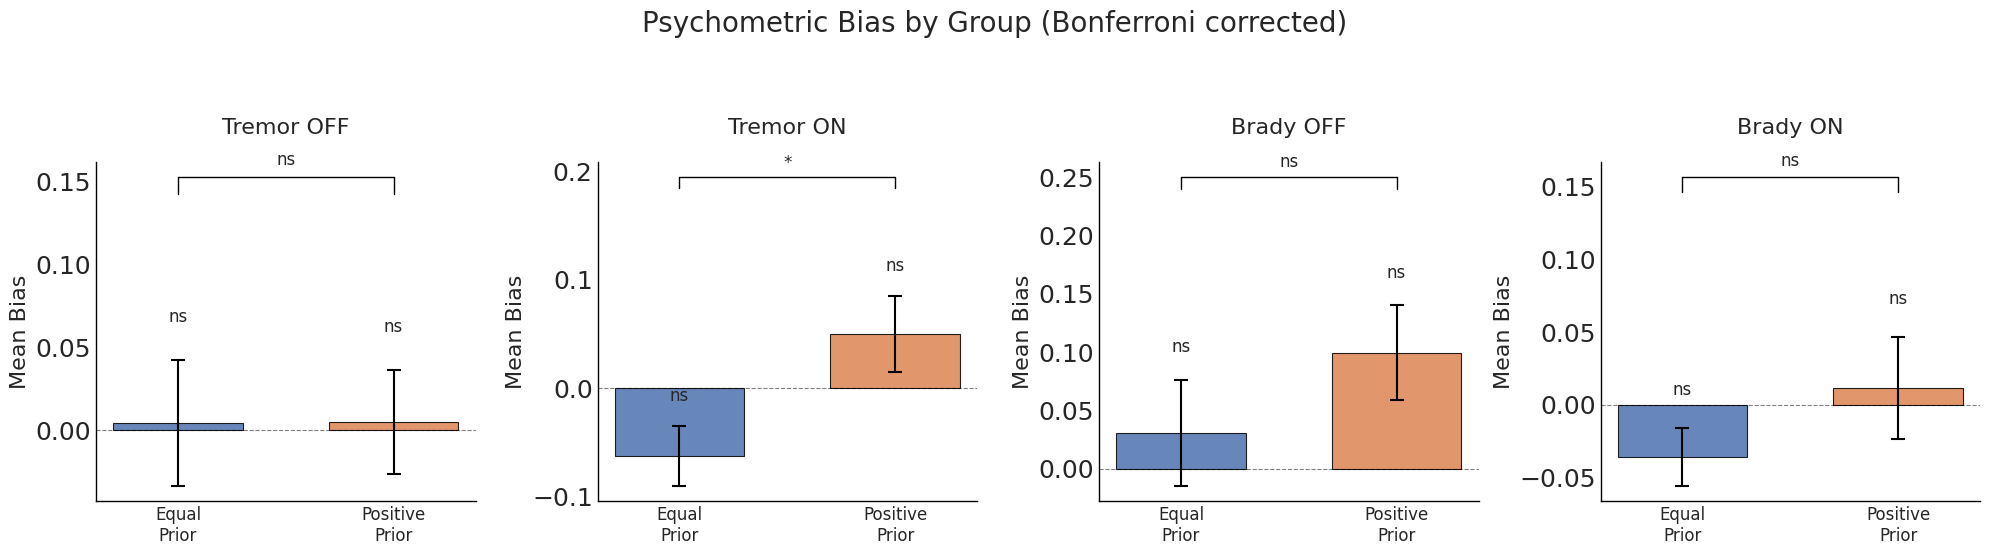

In [8]:
from src.utils.stats_utils import wilcoxon_battery
from scipy import stats as scipy_stats

test_labels = ["equal", "positive"]
test_xlabels = ["Equal\nPrior", "Positive\nPrior"]
bar_colors = ["#4C72B0", "#DD8452"]
bar_x = np.array([0, 1])

group_order = ["healthy", "pd_off", "pd_on", "tremor_off", "tremor_on", "brady_off", "brady_on"]
group_titles = {
    "healthy": "Healthy",
    "pd_off": "PD OFF",
    "pd_on": "PD ON",
    "tremor_off": "Tremor OFF",
    "tremor_on": "Tremor ON",
    "brady_off": "Brady OFF",
    "brady_on": "Brady ON",
}


for var in ["bias"]:  # , "psych_alpha", "psych_beta"]:
    fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
    fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))

    y_min, y_max = np.inf, -np.inf
    for grp in group_order:
        if grp in ["healthy", "pd_off", "pd_on"]:
            ax = axes1[["healthy", "pd_off", "pd_on"].index(grp)]
        else:
            ax = axes2[["tremor_off", "tremor_on", "brady_off", "brady_on"].index(grp)]
        group_data = psych_params.loc[grp_indices[grp]]
        pos_centered = group_data[f"positive_{var}"] if var != "bias" else group_data[f"positive_{var}"] - 0.5
        eq_centered = group_data[f"equal_{var}"] if var != "bias" else group_data[f"equal_{var}"] - 0.5

        results = wilcoxon_battery(
            tests={
                "equal": (eq_centered,),
                "positive": (pos_centered,),
                "positive_vs_equal": (group_data[f"positive_{var}"], group_data[f"equal_{var}"]),
            },
            print_results=False,
        ).set_index("test")

        diffs = {
            "equal": eq_centered,
            "positive": pos_centered,
        }

        bar_tops = {}
        for xi, (test_name, color) in enumerate(zip(test_labels, bar_colors)):
            vals = diffs[test_name].values
            mean = np.mean(vals)
            sem = scipy_stats.sem(vals)

            ax.bar(xi, mean, color=color, edgecolor="k", linewidth=0.8, width=0.6, alpha=0.85)
            ax.errorbar(xi, mean, yerr=sem, fmt="none", color="k", capsize=5, elinewidth=1.5, capthick=1.5)

            corr_p = results.loc[test_name, "corrected_p"]
            star = "***" if corr_p < 0.001 else "**" if corr_p < 0.01 else "*" if corr_p < 0.05 else "ns"
            ax.text(xi, mean + sem + 0.02, star, ha="center", va="bottom", fontsize=12)

            bar_tops[test_name] = mean + sem
            y_min = min(y_min, mean - sem)
            y_max = max(y_max, mean + sem + 0.08)

        bracket_y = max(bar_tops.values()) + 0.10
        p_vs_eq = results.loc["positive_vs_equal", "corrected_p"]
        p_str = "***" if p_vs_eq < 0.001 else "**" if p_vs_eq < 0.01 else "*" if p_vs_eq < 0.05 else "ns# p < 0.001" if p_vs_eq < 0.001 else "ns"  # f"p = {p_vs_eq:.3f}"
        ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + 0.01, bracket_y + 0.01, bracket_y], color="k", lw=1)
        ax.text(0.5, bracket_y + 0.015, p_str, ha="center", va="bottom", fontsize=12)

        y_max = max(y_max, bracket_y + 0.06)

        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
        ax.set_xticks(bar_x)
        ax.set_xticklabels(test_xlabels, fontsize=12)
        ax.set_title(group_titles[grp], fontsize=16, pad=20)
        ax.set_ylabel(f"Mean {var.capitalize().replace('_', ' ')}")
        ax.grid(False)

    # pad = (y_max - y_min) * 0.05
    # for ax in axes:
    #     ax.set_ylim(y_min - pad, y_max + pad)

    fig1.suptitle(f"Psychometric {var.capitalize().replace('_', ' ')} by Group (Bonferroni corrected)", y=1.1, fontsize=20)
    fig2.suptitle(f"Psychometric {var.capitalize().replace('_', ' ')} by Group (Bonferroni corrected)", y=1.1, fontsize=20)
    plt.tight_layout()
    plt.show()


# Difference of Difference analysis

Tests whether the **prior-induced bias** (positive − equal) differs between **medication states** (OFF vs ON) — i.e. whether L-DOPA modulates the effect of the color prior on choice.

- **Difference 1**: `positive_var − equal_var` (the prior effect), computed per subject, per medication state.
- **Difference 2**: that prior effect **ON** minus **OFF** medication (the DiD estimate).

OFF/ON are the same subjects, so this is fully within-subject on both axes — tests use paired Wilcoxon signed-rank (via `wilcoxon_battery`). Run separately for All PD, Tremor-dominant, and Brady-dominant.

In [9]:
did_group_order = ["pd", "tremor", "brady"]
did_group_titles = {"pd": "All PD", "tremor": "Tremor Dominant", "brady": "Brady Dominant"}

did_results = {}
for var in ["bias", "psych_alpha", "psych_beta"]:
    print(f"===== {var} =====")
    for grp in did_group_order:
        off_idx, on_idx = grp_indices[f"{grp}_off"], grp_indices[f"{grp}_on"]

        prior_effect_off = psych_params.loc[off_idx, f"positive_{var}"].to_numpy() - psych_params.loc[off_idx, f"equal_{var}"].to_numpy()
        prior_effect_on = psych_params.loc[on_idx, f"positive_{var}"].to_numpy() - psych_params.loc[on_idx, f"equal_{var}"].to_numpy()
        did_results[(var, grp)] = prior_effect_on - prior_effect_off  # per-subject DiD score

        results = wilcoxon_battery(
            tests={
                "prior_effect_off (vs 0)": (prior_effect_off,),
                "prior_effect_on (vs 0)": (prior_effect_on,),
                "DiD: on_effect vs off_effect": (prior_effect_on, prior_effect_off),
            },
            print_results=False,
        ).set_index("test")
        print(f"-- {did_group_titles[grp]} (n={len(prior_effect_off)}) --")
        print(results[["n", "p", "corrected_p", "cohen_d"]].round(4))
        print()

===== bias =====
-- All PD (n=41) --
                               n       p  corrected_p  cohen_d
test                                                          
prior_effect_off (vs 0)       41  0.8475       1.0000   0.1496
prior_effect_on (vs 0)        41  0.0075       0.0226   0.4493
DiD: on_effect vs off_effect  41  0.1555       0.4666   0.1608

-- Tremor Dominant (n=11) --
                               n       p  corrected_p  cohen_d
test                                                          
prior_effect_off (vs 0)       11  0.8311       1.0000   0.0040
prior_effect_on (vs 0)        11  0.0068       0.0205   1.0809
DiD: on_effect vs off_effect  11  0.1475       0.4424   0.5829

-- Brady Dominant (n=10) --
                               n       p  corrected_p  cohen_d
test                                                          
prior_effect_off (vs 0)       10  0.2324       0.6973   0.4746
prior_effect_on (vs 0)        10  0.3750       1.0000   0.3371
DiD: on_effect vs off_

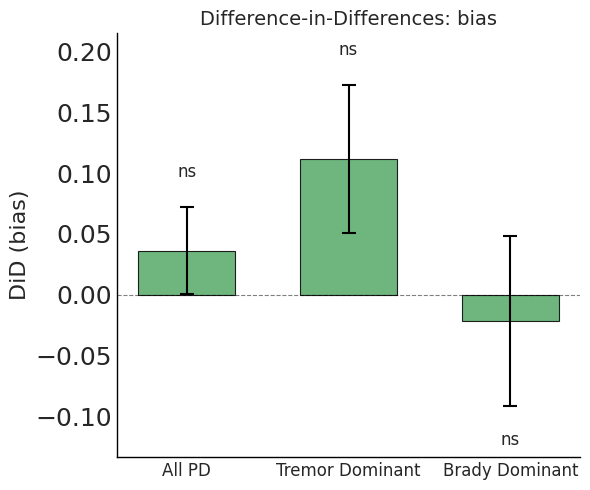

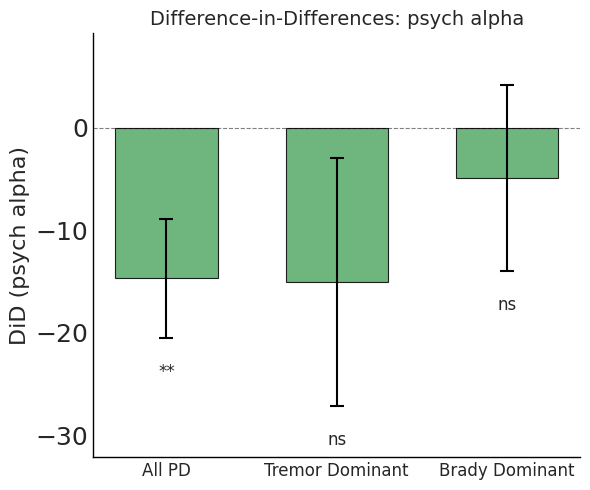

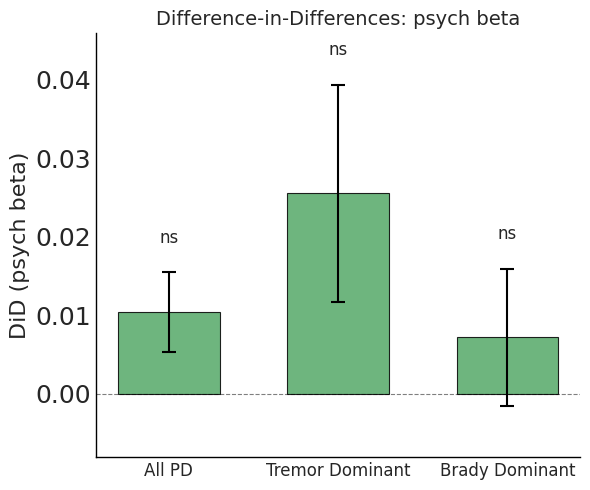

In [10]:
did_bar_color = "#55A868"

for var in ["bias", "psych_alpha", "psych_beta"]:
    fig, ax = plt.subplots(figsize=(6, 5))
    x = np.arange(len(did_group_order))
    means, sems, pvals = [], [], []
    for grp in did_group_order:
        did = did_results[(var, grp)]
        means.append(np.mean(did))
        sems.append(scipy_stats.sem(did))
        pvals.append(scipy_stats.wilcoxon(did).pvalue)
    means, sems = np.array(means), np.array(sems)

    ax.bar(x, means, color=did_bar_color, edgecolor="k", linewidth=0.8, width=0.6, alpha=0.85)
    ax.errorbar(x, means, yerr=sems, fmt="none", color="k", capsize=5, elinewidth=1.5, capthick=1.5)

    span = (means + sems).max() - (means - sems).min()
    pad = span * 0.08
    for xi, (m, s, p) in enumerate(zip(means, sems, pvals)):
        star = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        top = m + s if m >= 0 else m - s
        va = "bottom" if m >= 0 else "top"
        ax.text(xi, top + (pad if m >= 0 else -pad), star, ha="center", va=va, fontsize=12)

    ax.set_ylim((means - sems).min() - 2 * pad, (means + sems).max() + 2 * pad)
    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([did_group_titles[g] for g in did_group_order], fontsize=12)
    ax.set_ylabel(f"DiD ({var.replace('_', ' ')})")
    ax.set_title(f"Difference-in-Differences: {var.replace('_', ' ')}", fontsize=14)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    fig.tight_layout()
    plt.show()

### Interaction plot

Divergence in slope between the two lines from OFF → ON is the DiD effect: it shows whether medication changes the gap between positive- and equal-prior conditions.

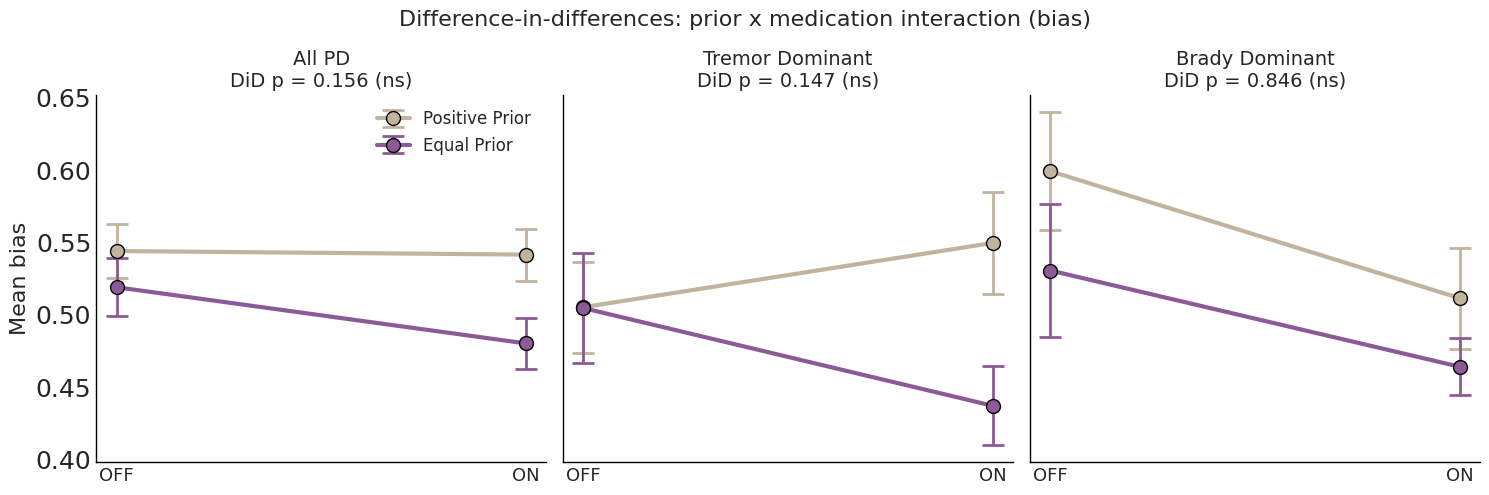

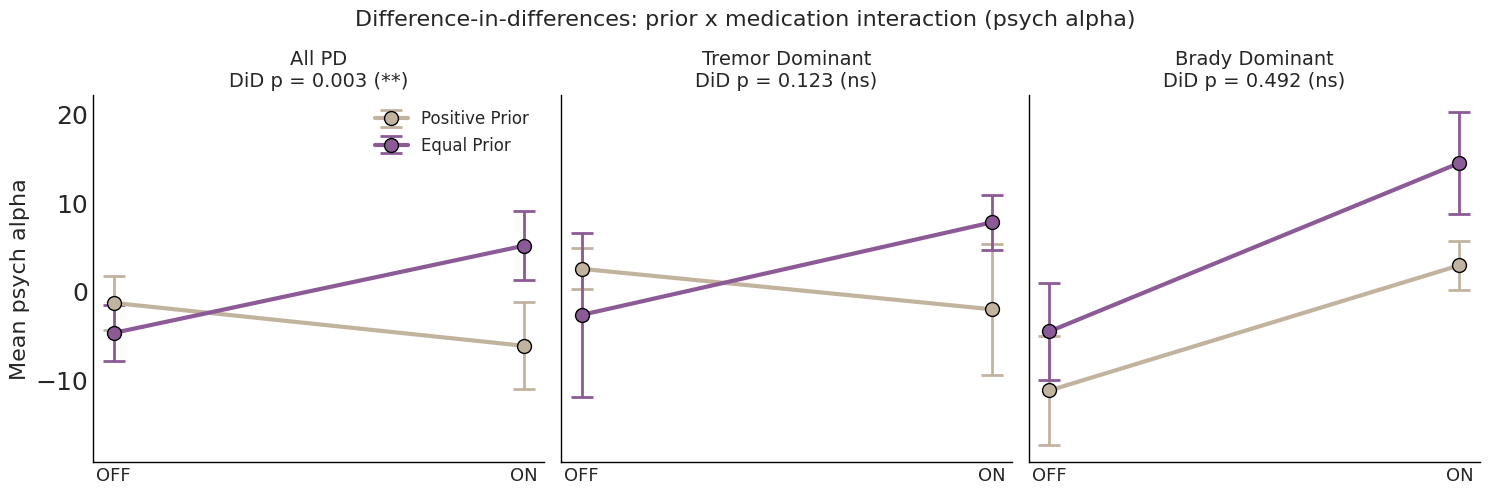

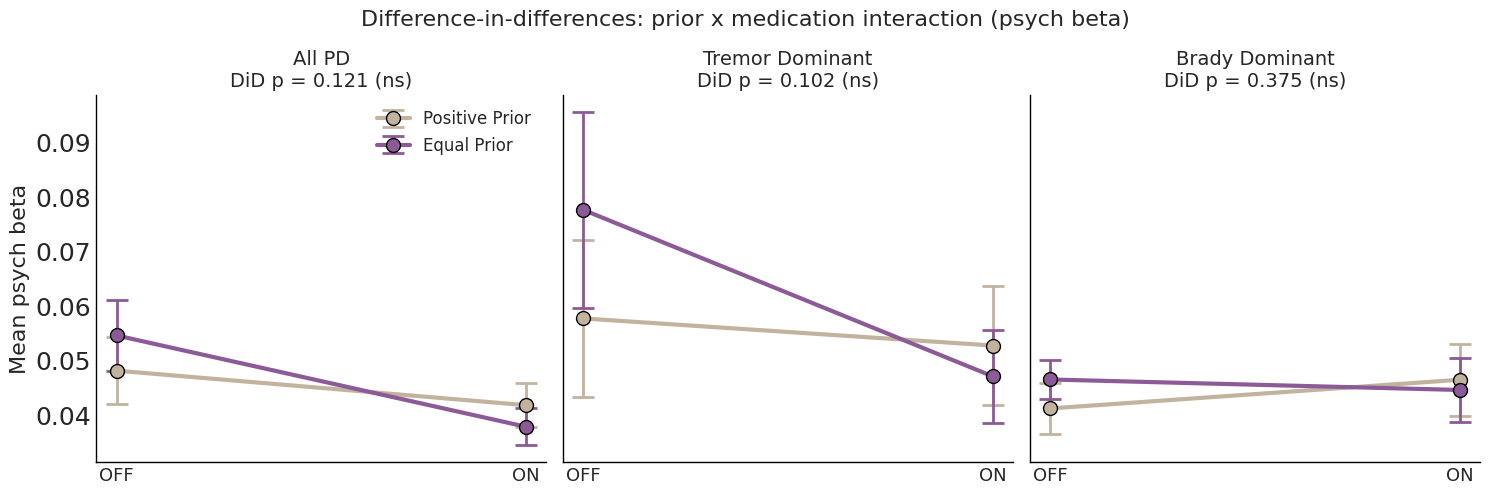

In [11]:
err_style = {"elinewidth": 2, "capsize": 8, "capthick": 2}

for var in ["bias", "psych_alpha", "psych_beta"]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for ax, grp in zip(axes, did_group_order):
        off_idx, on_idx = grp_indices[f"{grp}_off"], grp_indices[f"{grp}_on"]
        x = np.array([0, 1])
        for key, color, label in [("positive", pos_color, "Positive Prior"), ("equal", eq_color, "Equal Prior")]:
            vals_off = psych_params.loc[off_idx, f"{key}_{var}"].to_numpy()
            vals_on = psych_params.loc[on_idx, f"{key}_{var}"].to_numpy()
            means = [np.mean(vals_off), np.mean(vals_on)]
            sems = [scipy_stats.sem(vals_off), scipy_stats.sem(vals_on)]
            ax.errorbar(x, means, yerr=sems, color=color, marker="o", ms=10, mec="k", lw=3, label=label, **err_style)

        p_did = scipy_stats.wilcoxon(did_results[(var, grp)]).pvalue
        star = "***" if p_did < 0.001 else "**" if p_did < 0.01 else "*" if p_did < 0.05 else "ns"
        ax.set_xticks(x)
        ax.set_xticklabels(["OFF", "ON"], fontsize=13)
        ax.set_title(f"{did_group_titles[grp]}\nDiD p = {p_did:.3f} ({star})", fontsize=14)
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)

    axes[0].set_ylabel(f"Mean {var.replace('_', ' ')}")
    axes[0].legend(frameon=False)
    fig.suptitle(f"Difference-in-differences: prior x medication interaction ({var.replace('_', ' ')})", fontsize=16)
    fig.tight_layout()
    plt.show()

### Does the DiD effect differ by PD subtype?

Tremor- and Brady-dominant are different subjects, so this compares each subject's DiD score (computed above) between the two groups with a Mann-Whitney U test (between-subject, unpaired).

In [12]:
for var in ["bias", "psych_alpha", "psych_beta"]:
    did_tremor, did_brady = did_results[(var, "tremor")], did_results[(var, "brady")]
    u = scipy_stats.mannwhitneyu(did_tremor, did_brady)
    print(
        f"{var}: Tremor DiD = {np.mean(did_tremor):.3f} +/- {scipy_stats.sem(did_tremor):.3f} (n={len(did_tremor)}), "
        f"Brady DiD = {np.mean(did_brady):.3f} +/- {scipy_stats.sem(did_brady):.3f} (n={len(did_brady)}), "
        f"Mann-Whitney p = {u.pvalue:.3f}"
    )

bias: Tremor DiD = 0.112 +/- 0.061 (n=11), Brady DiD = -0.021 +/- 0.070 (n=10), Mann-Whitney p = 0.098
psych_alpha: Tremor DiD = -15.045 +/- 12.097 (n=11), Brady DiD = -4.895 +/- 9.074 (n=10), Mann-Whitney p = 0.860
psych_beta: Tremor DiD = 0.026 +/- 0.014 (n=11), Brady DiD = 0.007 +/- 0.009 (n=10), Mann-Whitney p = 0.805


# Trial-level mixed-effects model (GLMM)

The DiD tests above collapse each subject/medication/prior condition down to one fitted `bias` number, then run a paired Wilcoxon signed-rank test across subjects. That throws away all trial-level information, so with only n=11 (tremor) or n=10 (brady) subjects the DiD (interaction) test is underpowered even when the underlying effect is real — e.g. Tremor showed a highly significant prior effect *at ON* (p=0.0068) sitting right next to a null effect *at OFF* (p=0.83), yet the interaction test of those two only reached p=0.147.

Here we instead fit a **trial-level mixed-effects logistic regression** directly on single-trial choices:

`choice ~ coherence + color * medication`, with a **maximal by-subject random-effects structure** — random intercept + random slopes for `color`, `medication`, and their interaction (`statsmodels.BinomialBayesMixedGLM`, since raw trial counts run into the tens of thousands, plain `MixedLM` only supports Gaussian outcomes, and no R/`lme4`/`pymer4` is available in this environment).

- `color` (prior: positive=+0.5 / equal=−0.5) and `medication` (on=+0.5 / off=−0.5) are effect-coded so the `color:medication` coefficient is a clean interaction term — this is the trial-level analog of the DiD estimate above.
- `coherence` (scaled to ±1) is included as a fixed-effect covariate to soak up the psychometric slope, so the intercept-side terms isolate the *bias* (choice at zero coherence), matching what `bias` measured in the subject-level analysis.
- Random *slopes* (not just a random intercept) for `color`, `medication`, and `color:medication` per subject are essential here, not optional: with only a random intercept, the model could mistake genuine between-subject variability in how much medication changes prior-use for residual trial noise, understating uncertainty on the fixed-effect interaction (pseudoreplication). With the full structure, each subject is allowed their own slope, and the fixed-effect interaction represents the population-average slope after that variability is accounted for.

In [13]:
did_group_subjects = {
    "pd": subjects_map["all"],
    "tremor": subjects_map["tremor_dominant"],
    "brady": subjects_map["bradykinesia_dominant"],
}


def fit_trial_level_glmm(trial_data, subject_ids):
    """Fit choice ~ coherence + color * medication with a full by-subject random-effects structure
    (random intercept + random slopes for color, medication, and their interaction)."""
    df = trial_data[trial_data["subject_id"].isin(subject_ids) & trial_data["medication"].isin(["off", "on"])].copy()
    df["coh_scaled"] = df["signed_coherence"] / 100.0
    df["color_c"] = df["color"] - 0.5
    df["med_c"] = (df["medication"] == "on").astype(float) - 0.5

    model = sm.BinomialBayesMixedGLM.from_formula(
        "choice ~ coh_scaled + color_c * med_c",
        vc_formulas={
            "subject_intercept": "0 + C(subject_id)",
            "subject_color": "0 + C(subject_id):color_c",
            "subject_med": "0 + C(subject_id):med_c",
            "subject_colormed": "0 + C(subject_id):color_c:med_c",
        },
        data=df,
    )
    result = model.fit_vb()
    return result, df


glmm_results = {}
glmm_fits = {}
for grp in did_group_order:
    result, df = fit_trial_level_glmm(filtered_data, did_group_subjects[grp])
    glmm_fits[grp] = result

    fe_names = result.model.exog_names
    means = pd.Series(result.fe_mean, index=fe_names)
    sds = pd.Series(result.fe_sd, index=fe_names)

    term = "color_c:med_c"
    z = means[term] / sds[term]
    p = 2 * (1 - stats.norm.cdf(np.abs(z)))
    glmm_results[grp] = {"n_subjects": df["subject_id"].nunique(), "n_trials": len(df), "estimate": means[term], "sd": sds[term], "z": z, "p": p}

    print(f"-- {did_group_titles[grp]} (n_subjects={glmm_results[grp]['n_subjects']}, n_trials={glmm_results[grp]['n_trials']}) --")
    print(f"color:medication interaction: est={means[term]:.4f} +/- {sds[term]:.4f}, z={z:.3f}, p={p:.4g}")
    print()

-- All PD (n_subjects=41, n_trials=51830) --
color:medication interaction: est=0.1401 +/- 0.0409, z=3.425, p=0.0006141



-- Tremor Dominant (n_subjects=11, n_trials=13540) --
color:medication interaction: est=0.4706 +/- 0.0814, z=5.780, p=7.485e-09



-- Brady Dominant (n_subjects=10, n_trials=12549) --
color:medication interaction: est=0.0084 +/- 0.0853, z=0.098, p=0.9218



### Subject-level DiD vs. trial-level GLMM

In [14]:
comparison_rows = []
for grp in did_group_order:
    wilcoxon_p = scipy_stats.wilcoxon(did_results[("bias", grp)]).pvalue
    g = glmm_results[grp]
    comparison_rows.append(
        {
            "group": did_group_titles[grp],
            "n_subjects": g["n_subjects"],
            "n_trials": g["n_trials"],
            "wilcoxon_DiD_p (subject-level)": wilcoxon_p,
            "GLMM_interaction_p (trial-level)": g["p"],
            "GLMM_z": g["z"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("group")
comparison_df.round(4)

,n_subjects,n_trials,wilcoxon_DiD_p (subject-level),GLMM_interaction_p (trial-level),GLMM_z
group,,,,,
All PD,41,51830,0.1555,0.0006,3.4253
Tremor Dominant,11,13540,0.1475,0.0000,5.7797
Brady Dominant,10,12549,0.8457,0.9218,0.0982


### Interaction plot (model-predicted, trial-level)

Same layout as the earlier interaction plot, but the OFF/ON points are the GLMM's fixed-effects-only predicted choice probability at 0% coherence (i.e. the model's bias estimate), with 95% CIs from the posterior SDs of the fixed effects (mean-field VB, so these treat the fixed effects as independent — a reasonable approximation here, but not exact).

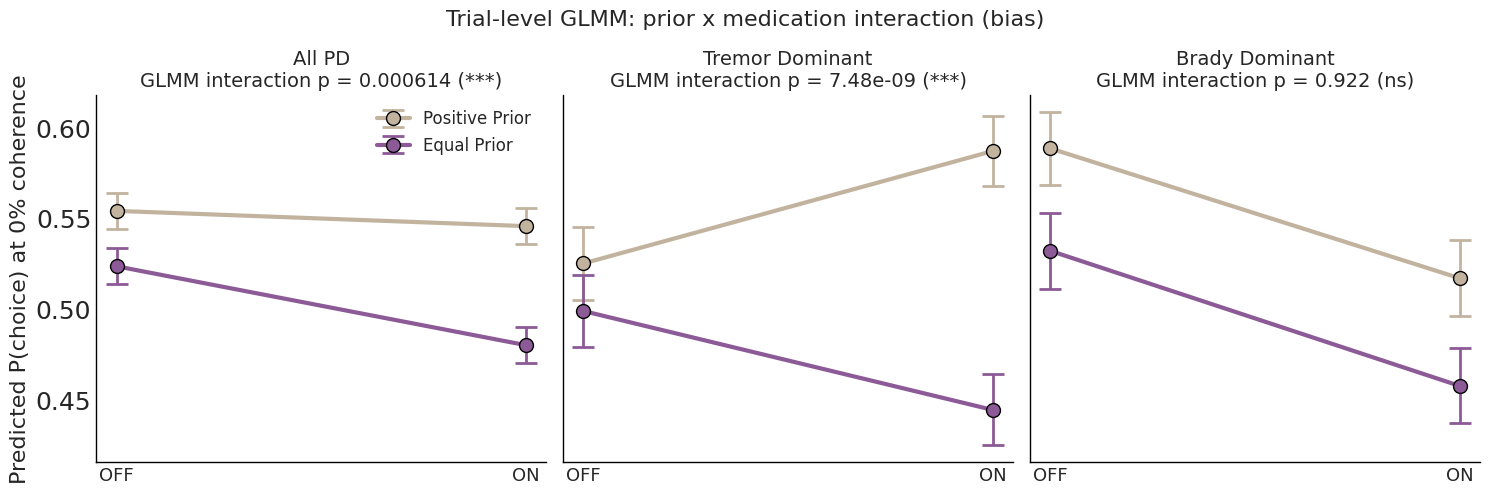

In [15]:
def predicted_prob_at_zero_coherence(result, color_val, med_val):
    """Fixed-effects-only predicted P(choice) at coh_scaled=0, with a 95% CI from the mean-field posterior SDs."""
    fe_names = result.model.exog_names
    means = pd.Series(result.fe_mean, index=fe_names)
    sds = pd.Series(result.fe_sd, index=fe_names)

    logit_mean = means["Intercept"] + means["color_c"] * color_val + means["med_c"] * med_val + means["color_c:med_c"] * color_val * med_val
    logit_var = sds["Intercept"] ** 2 + (color_val * sds["color_c"]) ** 2 + (med_val * sds["med_c"]) ** 2 + (color_val * med_val * sds["color_c:med_c"]) ** 2
    logit_sd = np.sqrt(logit_var)

    sigmoid = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
    return sigmoid(logit_mean), sigmoid(logit_mean - 1.96 * logit_sd), sigmoid(logit_mean + 1.96 * logit_sd)


err_style = {"elinewidth": 2, "capsize": 8, "capthick": 2}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, grp in zip(axes, did_group_order):
    result = glmm_fits[grp]
    x = np.array([0, 1])
    for key, color_val, color, label in [("positive", 0.5, pos_color, "Positive Prior"), ("equal", -0.5, eq_color, "Equal Prior")]:
        preds = [predicted_prob_at_zero_coherence(result, color_val, med_val) for med_val in (-0.5, 0.5)]
        probs = np.array([p[0] for p in preds])
        lo = np.array([p[1] for p in preds])
        hi = np.array([p[2] for p in preds])
        yerr = np.vstack([probs - lo, hi - probs])
        ax.errorbar(x, probs, yerr=yerr, color=color, marker="o", ms=10, mec="k", lw=3, label=label, **err_style)

    g = glmm_results[grp]
    star = "***" if g["p"] < 0.001 else "**" if g["p"] < 0.01 else "*" if g["p"] < 0.05 else "ns"
    ax.set_xticks(x)
    ax.set_xticklabels(["OFF", "ON"], fontsize=13)
    ax.set_title(f"{did_group_titles[grp]}\nGLMM interaction p = {g['p']:.3g} ({star})", fontsize=14)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

axes[0].set_ylabel("Predicted P(choice) at 0% coherence")
axes[0].legend(frameon=False)
fig.suptitle("Trial-level GLMM: prior x medication interaction (bias)", fontsize=16)
fig.tight_layout()
plt.show()

### Leave-one-subject-out sensitivity check

The GLMM correctly extracts more signal from each subject's trials than collapsing to one summary number, but it can't manufacture information about between-subject *heterogeneity* that isn't there — with only 11 (tremor) or 10 (brady) subjects, a single outlier could in principle be driving the whole population-level interaction. To check, refit the model once per subject with that subject held out, and see whether the `color:medication` estimate stays consistently on the same side of zero and significant.

("All PD", n=41, is skipped here — the full model alone takes ~15s to fit, so a 41-fold refit is expensive; the subtype-level results are the ones the interaction claim rests on anyway.)

In [16]:
def leave_one_subject_out(trial_data, subject_ids):
    """Refit the trial-level GLMM once per subject, holding that subject out each time."""
    rows = []
    for held_out in subject_ids:
        remaining = [s for s in subject_ids if s != held_out]
        result, _ = fit_trial_level_glmm(trial_data, remaining)

        fe_names = result.model.exog_names
        means = pd.Series(result.fe_mean, index=fe_names)
        sds = pd.Series(result.fe_sd, index=fe_names)
        term = "color_c:med_c"
        z = means[term] / sds[term]
        p = 2 * (1 - stats.norm.cdf(np.abs(z)))
        rows.append({"held_out_subject": held_out, "estimate": means[term], "sd": sds[term], "p": p})
    return pd.DataFrame(rows)


loso_results = {}
for grp in ["tremor", "brady"]:
    print(f"Leave-one-subject-out: {did_group_titles[grp]} ({len(did_group_subjects[grp])} refits)...")
    loso_results[grp] = leave_one_subject_out(filtered_data, did_group_subjects[grp])
    n_flips = (loso_results[grp]["p"] >= 0.05).sum()
    n_sign_flips = (np.sign(loso_results[grp]["estimate"]) != np.sign(glmm_results[grp]["estimate"])).sum()
    print(f"  full-sample estimate={glmm_results[grp]['estimate']:.4f} (p={glmm_results[grp]['p']:.3g})")
    print(f"  exclusions that drop below p<0.05: {n_flips}/{len(loso_results[grp])}; sign flips: {n_sign_flips}/{len(loso_results[grp])}")
    print()

Leave-one-subject-out: Tremor Dominant (11 refits)...


  full-sample estimate=0.4706 (p=7.48e-09)
  exclusions that drop below p<0.05: 0/11; sign flips: 0/11

Leave-one-subject-out: Brady Dominant (10 refits)...


  full-sample estimate=0.0084 (p=0.922)
  exclusions that drop below p<0.05: 10/10; sign flips: 5/10



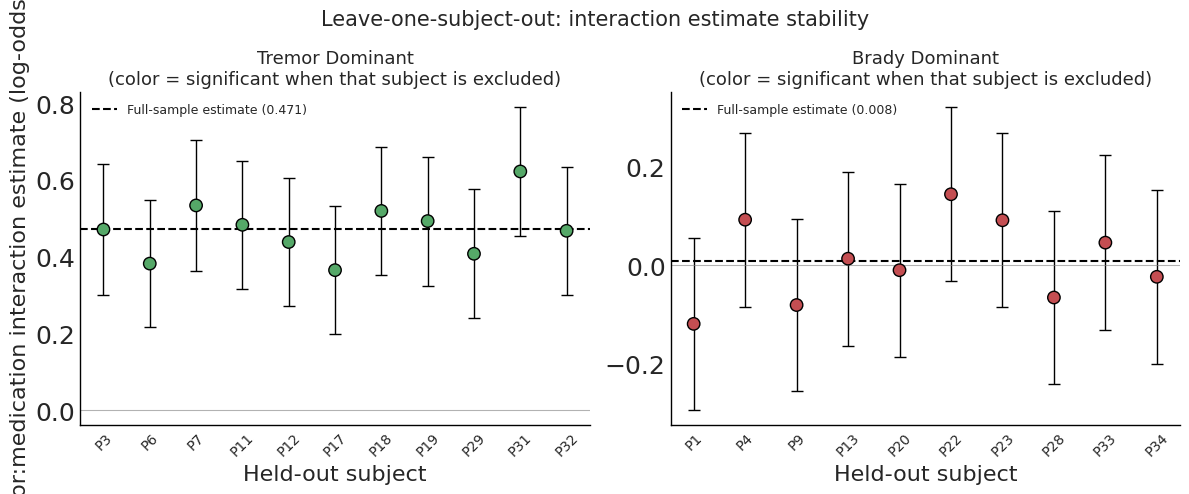

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, grp in zip(axes, ["tremor", "brady"]):
    loso = loso_results[grp]
    full_est = glmm_results[grp]["estimate"]
    point_colors = ["#C44E52" if p >= 0.05 else "#55A868" for p in loso["p"]]

    x = np.arange(len(loso))
    ax.errorbar(x, loso["estimate"], yerr=1.96 * loso["sd"], fmt="none", color="k", elinewidth=1, capsize=4, zorder=2)
    ax.scatter(x, loso["estimate"], c=point_colors, s=80, edgecolor="k", zorder=3)
    ax.axhline(full_est, color="k", ls="--", lw=1.5, label=f"Full-sample estimate ({full_est:.3f})")
    ax.axhline(0, color="gray", lw=0.8, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(loso["held_out_subject"], rotation=45, fontsize=10)
    ax.set_xlabel("Held-out subject")
    ax.set_title(f"{did_group_titles[grp]}\n(color = significant when that subject is excluded)", fontsize=13)
    ax.legend(frameon=False, fontsize=9, loc="best")
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

axes[0].set_ylabel("color:medication interaction estimate (log-odds)")
fig.suptitle("Leave-one-subject-out: interaction estimate stability", fontsize=15)
fig.tight_layout()
plt.show()